<a href="https://colab.research.google.com/github/rafi-shoishab/CSE715-VAE-Music-Clustering/blob/main/CSE715_VAE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import librosa
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
!pip install librosa tqdm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
os.listdir("/content/drive/MyDrive/CSE715")

['Data']

In [6]:
DATA_PATH = "/content/drive/MyDrive/CSE715/Data/genres_original"

In [7]:
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [8]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, duration=30)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

In [60]:
X = []
y = []

for genre in os.listdir(DATA_PATH):

    genre_path = os.path.join(DATA_PATH, genre)

    # ✅ skip non-directories (.DS_Store etc.)
    if not os.path.isdir(genre_path):
        continue

    for file in tqdm(os.listdir(genre_path)):
        file_path = os.path.join(genre_path, file)

        try:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(genre)
        except:
            pass

X = np.array(X)

 51%|█████▏    | 52/101 [00:02<00:02, 19.10it/s]/tmp/ipykernel_4472/503129895.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 100/100 [00:05<00:00, 17.48it/s]


In [61]:
X.shape

(1000, 40)

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled[:2]

array([[ 1.3631965 , -1.1760701 ,  0.34450656, -0.49219185,  0.9111621 ,
        -0.44741094,  1.0626385 , -0.02944194,  1.2120461 ,  0.08721845,
         0.9303211 ,  0.30754244,  0.89828473, -0.71099997,  0.9707983 ,
         0.40002552,  0.26401147,  0.5982468 ,  0.15578757,  0.5388556 ,
         0.21636362, -1.0766402 , -0.5055392 ,  0.03354941, -0.7702123 ,
         0.63828224,  0.31588134, -0.26082873, -0.08721427,  0.26220775,
        -2.2259936 , -1.6053209 , -1.5128615 , -0.23056103, -0.10130873,
        -0.60791296, -0.20359622, -0.10031717, -0.8396651 ,  0.18371712],
       [ 1.2117177 , -0.93555915,  0.5878968 , -0.47939014,  1.2215676 ,
        -0.7539984 ,  0.9176146 , -0.25638875,  1.1663147 ,  0.09581425,
         0.5491388 , -0.35753477,  0.23085006,  0.66619265,  0.759947  ,
        -0.17317645,  1.0007861 ,  0.9099198 ,  0.8665438 ,  1.3514391 ,
        -0.23264961, -0.05581791, -0.6167249 ,  0.5852062 ,  0.33582518,
         1.6642812 , -0.26279923,  0.40009472,  0.

In [63]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

print(device)

cuda


In [64]:
import torch.nn as nn

In [65]:
class VAE(nn.Module):

    def __init__(self, input_dim=40, latent_dim=8):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Latent parameters
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [66]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [67]:
def loss_fn(recon, x, mu, logvar):

    recon_loss = ((recon - x) ** 2).mean()

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu**2 - logvar.exp()
    )

    return recon_loss + kl_loss

In [68]:
for epoch in range(50):

    optimizer.zero_grad()

    recon, mu, logvar = model(X_tensor)

    loss = loss_fn(recon, X_tensor, mu, logvar)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.0249645709991455
Epoch: 1 Loss: 1.0211197137832642
Epoch: 2 Loss: 1.018964171409607
Epoch: 3 Loss: 1.0159653425216675
Epoch: 4 Loss: 1.0158063173294067
Epoch: 5 Loss: 1.0125629901885986
Epoch: 6 Loss: 1.011922001838684
Epoch: 7 Loss: 1.009374737739563
Epoch: 8 Loss: 1.0091248750686646
Epoch: 9 Loss: 1.008103370666504
Epoch: 10 Loss: 1.0078859329223633
Epoch: 11 Loss: 1.0074843168258667
Epoch: 12 Loss: 1.0076093673706055
Epoch: 13 Loss: 1.00527822971344
Epoch: 14 Loss: 1.0061588287353516
Epoch: 15 Loss: 1.0055404901504517
Epoch: 16 Loss: 1.0057719945907593
Epoch: 17 Loss: 1.00426185131073
Epoch: 18 Loss: 1.0042381286621094
Epoch: 19 Loss: 1.00327730178833
Epoch: 20 Loss: 1.0032845735549927
Epoch: 21 Loss: 1.0030221939086914
Epoch: 22 Loss: 1.0031702518463135
Epoch: 23 Loss: 1.003202199935913
Epoch: 24 Loss: 1.0026301145553589
Epoch: 25 Loss: 1.0029329061508179
Epoch: 26 Loss: 1.0013093948364258
Epoch: 27 Loss: 1.002922534942627
Epoch: 28 Loss: 1.002012848854065
Epoch: 2

In [69]:
with torch.no_grad():
    h = model.encoder(X_tensor)
    z = model.mu(h).cpu().numpy()

z.shape

(1000, 8)

In [70]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(z)

In [71]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil = silhouette_score(z, labels)
ch = calinski_harabasz_score(z, labels)

print("Silhouette Score:", sil)
print("Calinski-Harabasz:", ch)

Silhouette Score: 0.15424451
Calinski-Harabasz: 351.72314


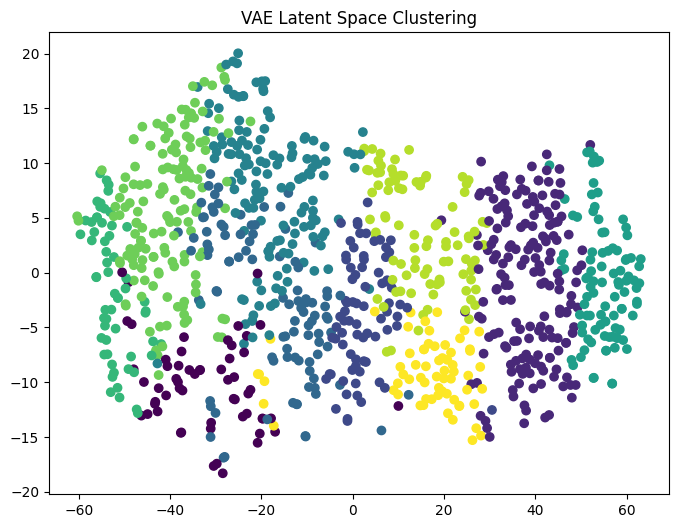

In [72]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z_2d = TSNE(n_components=2, random_state=42).fit_transform(z)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:,0], z_2d[:,1], c=labels)
plt.title("VAE Latent Space Clustering")
plt.show()

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
DATA_PATH = "/content/drive/MyDrive/CSE715/Data/genres_original"

In [75]:
import os
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [76]:
import os
import numpy as np
import librosa
from tqdm import tqdm

In [77]:
DATA_PATH = "/content/drive/MyDrive/CSE715/Data/genres_original"

In [78]:
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [79]:
genres = os.listdir(DATA_PATH)
genres

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [80]:
X = []
y = []

In [81]:
for genre in genres:

    if genre.startswith("."):
        continue

    genre_path = os.path.join(DATA_PATH, genre)

    if not os.path.isdir(genre_path):
        continue

    for file in tqdm(os.listdir(genre_path)):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(genre_path, file)

        try:
            signal, sr = librosa.load(file_path, duration=30)

            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
            mfcc_mean = np.mean(mfcc.T, axis=0)

            X.append(mfcc_mean)
            y.append(genre)

        except Exception as e:
            print(f"Skipping corrupted file: {file}")
            continue

X = np.array(X)
y = np.array(y)

 52%|█████▏    | 53/101 [00:02<00:02, 19.29it/s]/tmp/ipykernel_4472/3822473961.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 56%|█████▋    | 57/101 [00:03<00:03, 13.91it/s]

Skipping corrupted file: jazz.00054.wav


100%|██████████| 100/100 [00:06<00:00, 16.41it/s]


In [82]:
print(X.shape)
print(len(y))

(1000, 40)
1000


In [83]:
import pandas as pd
os.makedirs("results", exist_ok=True)

df = pd.DataFrame(X)
df["label"] = y

df.to_csv("results/features.csv", index=False)

In [84]:
os.listdir("results")

['features.csv']

In [85]:
print(X.shape)
os.listdir("results")

(1000, 40)


['features.csv']

In [86]:
# medium task

In [87]:
import tensorflow as tf
from tensorflow.keras import layers, Model

In [88]:
input_dim = 40   # from your data
latent_dim = 2   # for visualization

In [89]:
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation='relu')(inputs)
h = layers.Dense(32, activation='relu')(h)

z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

In [90]:
import tensorflow.keras.backend as K

def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [91]:
decoder_h1 = layers.Dense(32, activation='relu')
decoder_h2 = layers.Dense(64, activation='relu')
decoder_output = layers.Dense(input_dim, activation='linear')

h_decoded = decoder_h1(z)
h_decoded = decoder_h2(h_decoded)
outputs = decoder_output(h_decoded)

In [92]:
vae = Model(inputs, outputs)

In [93]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(inputs - reconstructed), axis=1)
        )

        # KL loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        self.add_loss(reconstruction_loss + kl_loss)
        return reconstructed

In [94]:
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

In [95]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(32, activation='relu')(latent_inputs)
x = layers.Dense(64, activation='relu')(x)
outputs_dec = layers.Dense(input_dim, activation='linear')(x)

decoder = Model(latent_inputs, outputs_dec, name="decoder")

In [96]:
vae = VAE(encoder, decoder)

vae.compile(optimizer='adam')

In [97]:
vae.fit(X_scaled, epochs=50, batch_size=32)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 40.3963
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.2314
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.5327
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.5715
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.3844
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.4530
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.8089
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.3389
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.0832
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.9705
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.6589
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.5854
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.4476
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.3382
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.2200
Epo

In [98]:
z_mean, z_log_var, z = encoder.predict(X_scaled)
latent_vectors = z_mean

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(latent_vectors)

print(clusters[:10])

[3 3 3 0 3 0 0 3 3 0]


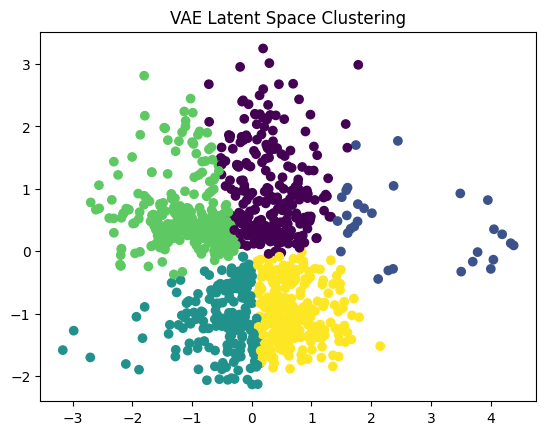

In [100]:
import matplotlib.pyplot as plt

plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1], c=clusters)
plt.title("VAE Latent Space Clustering")
plt.show()

In [101]:
from sklearn.metrics import silhouette_score

score = silhouette_score(latent_vectors, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.36076856


In [102]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(latent_vectors)

In [103]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(latent_vectors)

# Remove noise points (-1)
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    print("Silhouette Score (DBSCAN):",
          silhouette_score(latent_vectors[mask], db_labels[mask]))
else:
    print("DBSCAN failed or all noise")

Silhouette Score (DBSCAN): 0.5890852


In [104]:
from sklearn.metrics import calinski_harabasz_score

print(calinski_harabasz_score(latent_vectors, clusters))

628.9871


In [105]:
from sklearn.metrics import davies_bouldin_score

print(davies_bouldin_score(latent_vectors, clusters))

0.9558322859277792


In [106]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=5)
pca_clusters = kmeans.fit_predict(pca_features)

In [107]:
# Agglomerative
print("Agg Silhouette:", silhouette_score(latent_vectors, agg_labels))
print("Agg CH:", calinski_harabasz_score(latent_vectors, agg_labels))
print("Agg DB:", davies_bouldin_score(latent_vectors, agg_labels))

# PCA baseline
print("PCA Silhouette:", silhouette_score(pca_features, pca_clusters))
print("PCA CH:", calinski_harabasz_score(pca_features, pca_clusters))
print("PCA DB:", davies_bouldin_score(pca_features, pca_clusters))

Agg Silhouette: 0.31790558
Agg CH: 541.7295
Agg DB: 1.0089270606581273
PCA Silhouette: 0.40206653
PCA CH: 961.50757
PCA DB: 0.8489225655341744


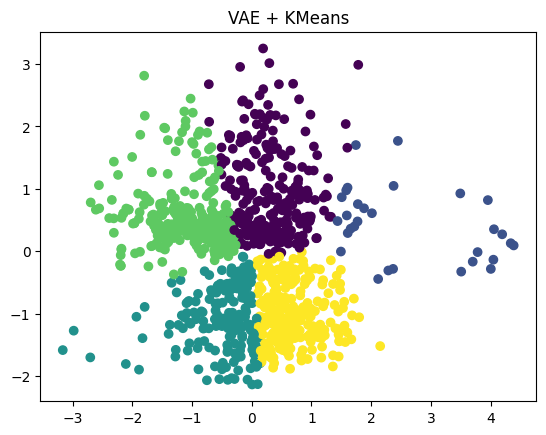

In [108]:
plt.scatter(latent_vectors[:,0], latent_vectors[:,1], c=clusters)
plt.title("VAE + KMeans")
plt.show()

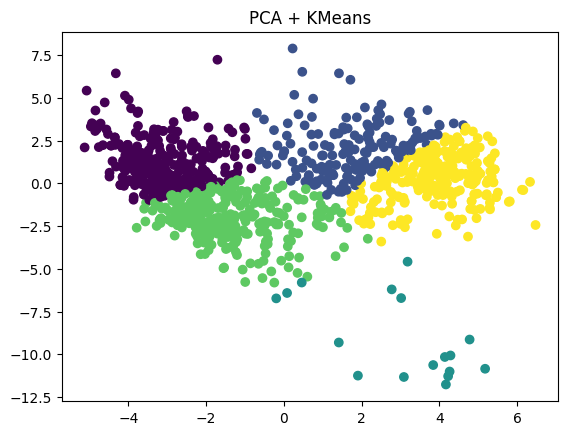

In [109]:
plt.scatter(pca_features[:,0], pca_features[:,1], c=pca_clusters)
plt.title("PCA + KMeans")
plt.show()